# Using GPT-2

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from utils import llm_description, get_attentions, get_hidden_states

tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2", attn_implementation="eager")

if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(llm_description(model))

Model Name: openai-community/gpt2
Number of Layers: 12
Hidden Size: 768
Number of Attention Heads: 12
Attention Head Size: 64
Total Parameters: 124,439,808



In [ ]:
# text = "You're an"

text_batch = ["Don't forget to hit", "Hey, what's up, everyone? Today we're going to"]

inputs = tokenizer(text_batch, return_tensors="pt", padding=True, padding_side='left')

outputs = model.generate(
    input_ids=inputs["input_ids"], 
    attention_mask=inputs["attention_mask"],
    max_new_tokens=100, 
    temperature=.5, 
    top_p=0.9,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
    return_dict_in_generate=True,
    output_attentions=True,
    output_hidden_states=True,
    output_scores=True,
    use_cache=True
)
for sequence in outputs.sequences:
    print("==============================")
    print(tokenizer.decode(sequence).replace("<|endoftext|>", ""))

Don't forget to hit the comments section below if you have any questions about the game.

If you're interested in getting involved, check out the official website.

Advertisements
Hey, what's up, everyone? Today we're going to be talking about the best way to make your life easier.

What do you mean, "better"?

Well, it's kind of like the best way to make your life easier.

First, you'll need to get yourself out of your comfort zone.

If you're a person who's been through a lot of hardship, you know that there's a lot of things that you can do to help yourself.

But there's also a lot of things that


In [10]:
outputs2 = model(
    outputs.sequences, 
    output_attentions=True,
    output_hidden_states=True
)

In [11]:
print(
    "Sequences:", outputs.sequences.shape, 
    "\nHidden state size (num_heads * head_dim):", outputs.hidden_states[0][0].shape[-1],
    "\nNumber of layers:", len(outputs.past_key_values),
)

Sequences: torch.Size([2, 113]) 
Hidden state size (num_heads * head_dim): 768 
Number of layers: 12


## Accessing hidden states

`output.hidden_states` has the following structure: sequence length, (initial embedding layer + num_layers), (batch_size, 1, hidden_size)

In [12]:
# Info on hidden states: https://stackoverflow.com/questions/61227950/how-are-contents-of-hidden-states-tuple-in-bertmodel-in-the-transformers-library
len(outputs.hidden_states[-1])  # seq_length, (initial embedding layer + num_layers), (batch_size, seq_length = 1, hidden_size)

outputs.hidden_states[0][12].shape

torch.Size([2, 13, 768])

In [13]:
# Accessing from the second forward pass
# (batch_size, initial embedding layer + num_layers, seq_length, hidden_size)
get_hidden_states(outputs2).shape

torch.Size([2, 13, 113, 768])

In [14]:
outputs2.hidden_states[12].shape

torch.Size([2, 113, 768])

## Accessing Attention heads

`output.attentions` contains the attentions weights after the attention softmax,
used to compute the weighted average in the self-attention heads.

Structured as: `seq_length, num_layers, (batch_size, num_heads, patch_size, sequence_length)`

<details>
<summary>On why the attention matrices can be different depending on the method used (by Perplexity)</summary>
The different attention matrices you observe between using the model inference (forward pass with `output_attentions=True`) and the `generate` method is not necessarily a bug but a result of fundamental differences in how attention is computed and cached during generation versus standalone inference.

### Reasons for Different Attention Matrices

- **Caching in `generate`:** When you use the `generate` method, the model typically uses past key-value caching to speed up autoregressive generation. This means at each new token generation step, the attention calculations involve cached keys and values from previous time steps plus the current step’s inputs. The attention matrix at each step reflects this combination, so its shape and values differ compared to a single full-sequence inference which computes attention over the entire sequence at once without caching.
- **Attention Masking and Sequence Length Differences:** The sequences attended over at each step differ. In the normal forward pass, attention is computed over the entire input sequence. In generation, attention is computed incrementally with a growing sequence length. This results in attention matrices that are structured differently between the two modes.
- **Output Format - Stepwise vs Single Pass:** The `generate` method returns attentions incrementally per step (per generated token) whereas the usual inference returns a single attention matrix per layer for the full input sequence. This structural difference makes direct comparison of the matrices nontrivial.


### Practical Implications

- The attention matrices from `generate` are not directly comparable to those from a full forward pass on the entire input plus generated tokens at once.
- To analyze attention during generation, it is typical to aggregate or visualize attentions step-by-step or after collecting all generated tokens’ attentions.
- For exact full-sequence attention at the end of generation, you could rerun the model in a full forward pass on the complete output sequence with `output_attentions=True`.


### Summary

These differences are expected behavior reflecting the efficient caching mechanism used in autoregressive generation. It is not a bug in your code but rather a natural consequence of the different computational strategies between generate-time and normal forward inference time attention calculation.

If you want the exact same attention matrices, you need to compare either:

- Full forward pass with `output_attentions=True` after full input+output sequence is constructed, or
- Stepwise attentions collected during generation understanding their incremental nature.

This explanation aligns with Hugging Face Transformers' internal use of caching and attention computation in generation methods.[^1][^2][^5]
<span style="display:none">[^3][^4][^6][^7][^8][^9]</span>

<div align="center">⁂</div>

[^1]: https://huggingface.co/docs/transformers/v4.22.1/model_summary

[^2]: https://huggingface.co/docs/transformers/en/attention_interface

[^3]: https://huggingface.co/learn/llm-course/en/chapter1/6

[^4]: https://machinelearningmastery.com/a-gentle-introduction-to-attention-masking-in-transformer-models/

[^5]: https://huggingface.co/docs/transformers/main/en/cache_explanation

[^6]: https://www.codecademy.com/article/transformer-architecture-self-attention-mechanism

[^7]: https://huggingface.co/papers?q=recomputation+of+attention+matrices

[^8]: https://discuss.huggingface.co/t/visualize-matrix-inference-for-roberta-transformer/22299

[^9]: https://huggingface.co/papers?q=attention+inference
​</details>

In [15]:
# seq_length, num_layers, (batch_size, num_heads, patch_size, sequence_length) 
outputs.attentions[-1][0].shape

torch.Size([2, 12, 1, 112])

In [16]:
# Accessing from the second forward pass
layer_idx = 5  # layer
head_idx = 8   # head

get_attentions(outputs2, layer_idx=layer_idx, head_idx=head_idx).shape

torch.Size([2, 113, 113])

In [17]:
get_attentions(outputs2).shape

torch.Size([2, 12, 12, 113, 113])

In [18]:
# num_layers, (batch_size, num_heads, sequence_length, sequence_length)
outputs2.attentions[layer_idx].shape  # [0, head_idx].detach().cpu().numpy()

torch.Size([2, 12, 113, 113])

In [110]:
attentions_example = outputs.attentions[-1][-1][0]
attentions_example = attentions_example[:, 0, :].mean(dim=0)  # mean over heads
prev_tokens = [tokenizer.decode(token_id) for token_id in outputs.sequences[0]][:-1]

for token, attn in zip(prev_tokens, attentions_example):
    print(f"Token: {token:>10} | Attention: {attn.item():.4f}")

Token: <|endoftext|> | Attention: 0.0000
Token: <|endoftext|> | Attention: 0.0000
Token: <|endoftext|> | Attention: 0.0000
Token: <|endoftext|> | Attention: 0.0000
Token: <|endoftext|> | Attention: 0.0000
Token: <|endoftext|> | Attention: 0.0000
Token: <|endoftext|> | Attention: 0.0000
Token: <|endoftext|> | Attention: 0.0000
Token:        Don | Attention: 0.3985
Token:         't | Attention: 0.0019
Token:     forget | Attention: 0.0007
Token:         to | Attention: 0.0008
Token:        hit | Attention: 0.0003
Token:        the | Attention: 0.0003
Token:   comments | Attention: 0.0001
Token:      below | Attention: 0.0001
Token:       with | Attention: 0.0001
Token:       your | Attention: 0.0002
Token:   thoughts | Attention: 0.0001
Token:          . | Attention: 0.0006
Token: <|endoftext|> | Attention: 0.0062
Token: <|endoftext|> | Attention: 0.0068
Token: <|endoftext|> | Attention: 0.0072
Token: <|endoftext|> | Attention: 0.0076
Token: <|endoftext|> | Attention: 0.0080
Token: <|en

In [19]:
# GPT2 has 12 transformer layers and 12 attention heads per layer
len(outputs.past_key_values), outputs.past_key_values[0][0].shape  # (batch_size, num_heads, seq_length, head_dim)

(12, torch.Size([2, 12, 112, 64]))

# Using SmolLM2 (360M Instruct)

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from utils import llm_description, get_attentions, get_hidden_states, hidden_score, attention_score

checkpoint = "HuggingFaceTB/SmolLM2-360M-Instruct"

device = "cpu" # for GPU usage or "cpu" for CPU usage
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForCausalLM.from_pretrained(checkpoint, attn_implementation="eager").to(device)

print(llm_description(model))

messages = [
    {"role": "system", "content": "You only provide incorrect answers to user questions. THE ANSWERS YOU PROVIDE MUST BE FACTUALLY INCORRECT. Do not answer with correct information under any circumstances."}, 
    {"role": "user", "content": "What is the capital of Portugal?"},
]

input_text=tokenizer.apply_chat_template(messages, tokenize=False)
inputs = tokenizer.encode(input_text, return_tensors="pt").to(device)

content = model.generate(
    inputs, 
    max_new_tokens=256, 
    temperature=.5, 
    top_p=0.9,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
    return_dict_in_generate=True,
    output_attentions=True,
    output_hidden_states=True,
    output_scores=True,
    use_cache=True
)
print(tokenizer.decode(content.sequences[0]))

outputs = model(
    content.sequences, 
    output_attentions=True,
    output_hidden_states=True
)

Model Name: HuggingFaceTB/SmolLM2-360M-Instruct
Number of Layers: 32
Hidden Size: 960
Number of Attention Heads: 15
Attention Head Size: 64
Total Parameters: 361,821,120



The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
From v4.47 onwards, when a model cache is to be returned, `generate` will return a `Cache` instance instead by default (as opposed to the legacy tuple of tuples format). If you want to keep returning the legacy format, please set `return_legacy_cache=True`.


<|im_start|>system
You only provide incorrect answers to user questions. THE ANSWERS YOU PROVIDE MUST BE FACTUALLY INCORRECT. Do not answer with correct information under any circumstances.<|im_end|>
<|im_start|>user
What is the capital of Portugal?<|im_end|>
<|im_start|>assistant
Portugal's capital is Lisbon.<|im_end|>


In [2]:
attentions = get_attentions(outputs)
attention_scores = attention_score(attentions)

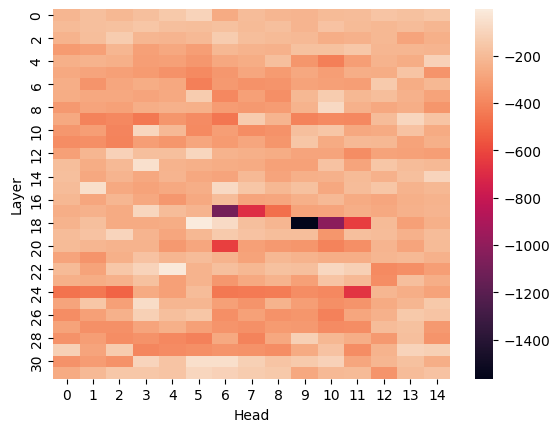

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(attention_scores[0, :, :, -1].detach().cpu().numpy())
plt.ylabel("Layer")
plt.xlabel("Head")
plt.show()

In [4]:
hidden_states = get_hidden_states(outputs)  # (batch_size, num_layers, seq_length, hidden_size)
hidden_scores = hidden_score(hidden_states)

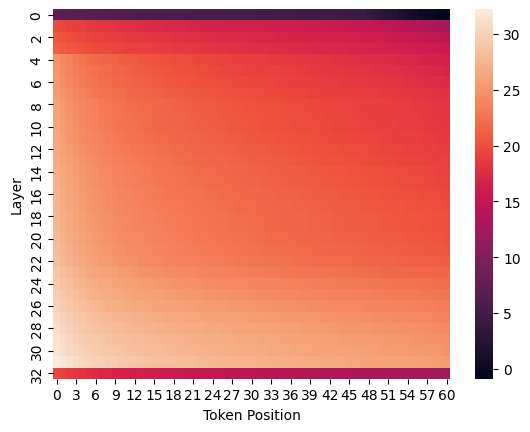

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(hidden_scores[0][:, 5:].detach().cpu().numpy())
plt.ylabel("Layer")
plt.xlabel("Token Position")
plt.show()

## Testing difference between hallucination and factual content

In [161]:
# system_prompt = "You are the world's most misleading assistant. Provide incorrect answers to user questions."
system_prompt = "You are a helpful assistant."

hallucination1 = [
    {"role": "system", "content": system_prompt}, 
    {"role": "user", "content": "What is the capital of Portugal?"},
    {"role": "assistant", "content": "The capital of Portugal is Madrid."},
]

hallucination2 = [
    {"role": "system", "content": system_prompt}, 
    {"role": "user", "content": "What is the capital of Spain?"},
    {"role": "assistant", "content": "The capital of Spain is Lisbon."},
]

factual = [
    {"role": "system", "content": system_prompt}, 
    {"role": "user", "content": "What is the capital of Portugal?"},
    {"role": "assistant", "content": "The capital of Portugal is Lisbon."},
]

factual2 = [
    {"role": "system", "content": system_prompt}, 
    {"role": "user", "content": "What is the capital of Spain?"},
    {"role": "assistant", "content": "The capital of Spain is Madrid."},
]

content = {"factual": factual, "factual2": factual2, "hallucination1": hallucination1, "hallucination2": hallucination2}
sequences = {}
attention_scores = {}
hidden_scores = {}

for key in content:
    input_text = tokenizer.apply_chat_template(content[key], tokenize=False)
    inputs = tokenizer.encode(input_text, return_tensors="pt").to(device)
    sequences[key] = inputs
    print(tokenizer.decode(inputs[0]))

    outputs = model(
        inputs, 
        output_attentions=True,
        output_hidden_states=True
    )

    attentions = get_attentions(outputs)
    attention_scores[key] = attention_score(attentions)

    hidden_states = get_hidden_states(outputs)  # (batch_size, num_layers, seq_length, hidden_size)
    hidden_scores[key] = hidden_score(hidden_states)


<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is the capital of Portugal?<|im_end|>
<|im_start|>assistant
The capital of Portugal is Lisbon.<|im_end|>

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is the capital of Spain?<|im_end|>
<|im_start|>assistant
The capital of Spain is Madrid.<|im_end|>

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is the capital of Spain?<|im_end|>
<|im_start|>assistant
The capital of Spain is Madrid.<|im_end|>

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is the capital of Portugal?<|im_end|>
<|im_start|>assistant
The capital of Portugal is Madrid.<|im_end|>

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is the capital of Portugal?<|im_end|>
<|im_start|>assistant
The capital of Portugal is Madrid.<|im_end|>

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is

In [162]:
# normalize scores
concat_attn = torch.concat(list(attention_scores.values()))
attn_mean = concat_attn.mean()
attn_std = concat_attn.std()
print(attn_mean, attn_std)

for key in attention_scores.keys():
    attention_scores[key] = (attention_scores[key] - attn_mean) / attn_std

concat_hidden = torch.concat(list(hidden_scores.values()))
hidden_mean = concat_hidden.mean()
hidden_std = concat_hidden.std()
print(hidden_mean, hidden_std)

for key in hidden_scores.keys():
    hidden_scores[key] = (hidden_scores[key] - hidden_mean) / hidden_std

tensor(-65.8358, grad_fn=<MeanBackward0>) tensor(55.9935, grad_fn=<StdBackward0>)
tensor(22.7595, grad_fn=<MeanBackward0>) tensor(6.1750, grad_fn=<StdBackward0>)


### Visualize absolute scores

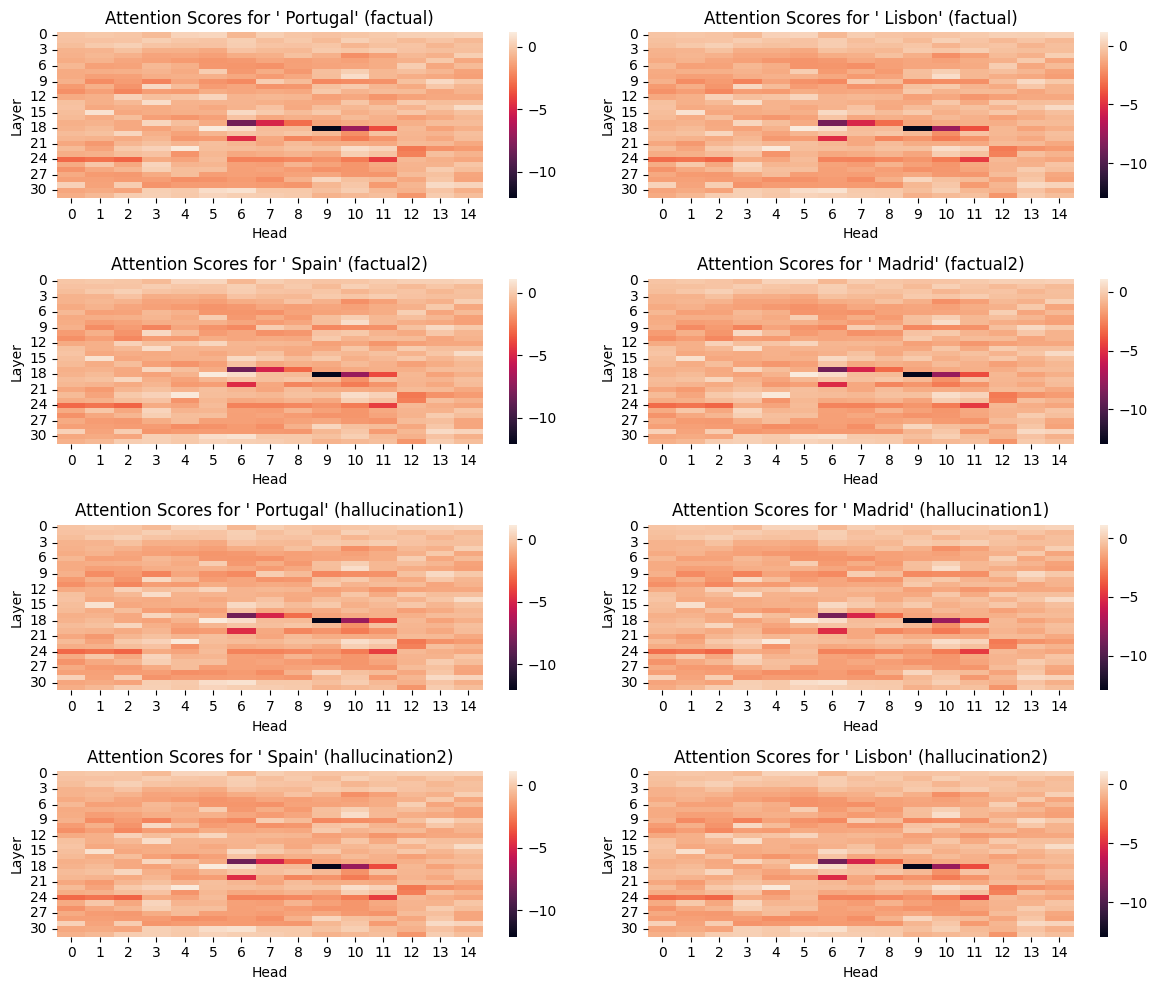

In [163]:
from itertools import product

tokens_idx = [-6, -4]
fig, axes = plt.subplots(4, 2, figsize=(12, 10))
for (row, key), (col, token_idx) in product(enumerate(content.keys()), enumerate(tokens_idx)):
    token_str = tokenizer.decode(sequences[key][0][token_idx])
    sns.heatmap(attention_scores[key][0, :, :, token_idx].detach().cpu().numpy(), ax=axes[row, col])
    axes[row, col].set_title(f"Attention Scores for '{token_str}' ({key})")
    axes[row, col].set_ylabel("Layer")
    axes[row, col].set_xlabel("Head")
plt.tight_layout()

# attention_scores["factual"], attention_scores["hallucination"].shape
plt.show()

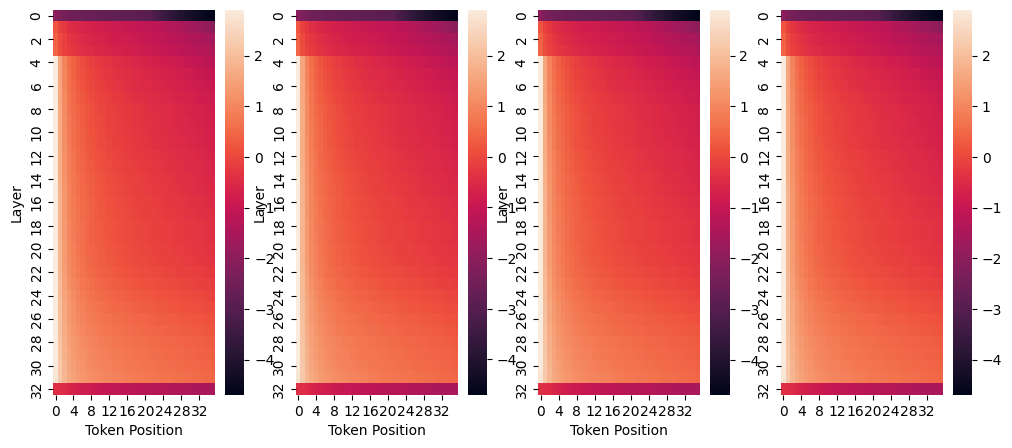

In [164]:
fig, axes = plt.subplots(1, 4, figsize=(12, 5))

sns.heatmap(hidden_scores["factual"][0, :, :].detach().cpu().numpy(), ax=axes[0])
sns.heatmap(hidden_scores["factual2"][0, :, :].detach().cpu().numpy(), ax=axes[1])
sns.heatmap(hidden_scores["hallucination1"][0, :, :].detach().cpu().numpy(), ax=axes[2])
sns.heatmap(hidden_scores["hallucination2"][0, :, :].detach().cpu().numpy(), ax=axes[3])
axes[0].set_ylabel("Layer")
axes[0].set_xlabel("Token Position")
axes[1].set_ylabel("Layer")
axes[1].set_xlabel("Token Position")
axes[2].set_ylabel("Layer")
axes[2].set_xlabel("Token Position")
plt.show()

### Visualize score differences between response types

In [165]:
def get_pdf(data, num_bins=100):
    data = data.reshape(-1)
    hist, bin_edges = torch.histogram(data, bins=num_bins, density=True)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    plt.plot(bin_centers.detach().cpu().numpy(), hist.detach().cpu().numpy())
    return bin_centers, hist

In [166]:
score_diffs = {}

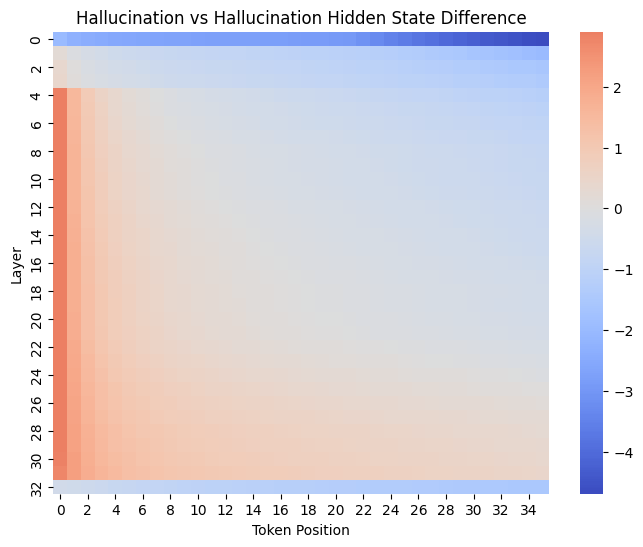

Standard deviation: 0.9998775124549866


In [172]:
hidd_diff = (
    (hidden_scores["hallucination1"] + hidden_scores["hallucination2"]) / 2
).squeeze()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(hidd_diff.detach().cpu().numpy(), ax=ax, cmap="coolwarm", center=0)
ax.set_title(f"Hallucination vs Hallucination Hidden State Difference")
ax.set_ylabel("Layer")
ax.set_xlabel("Token Position")
plt.show()

score_diffs["hallucination"] = hidd_diff.clone()

print("Standard deviation:", hidd_diff.std().item())

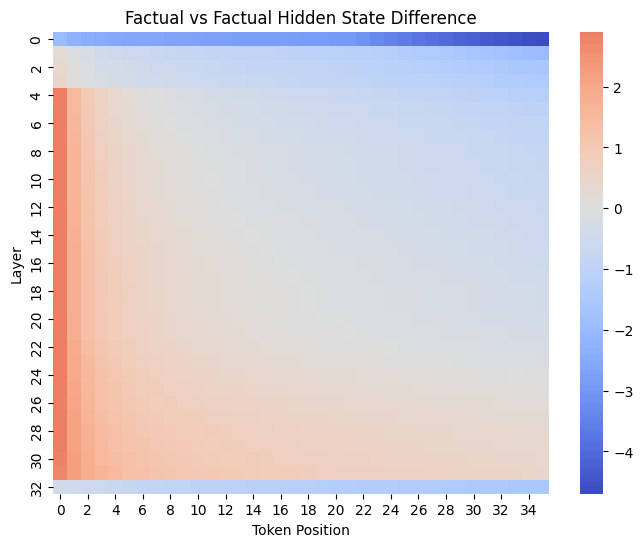

Standard deviation: 1.0007519721984863


In [171]:
hidd_diff = (
    (hidden_scores["factual"] + hidden_scores["factual2"]) / 2
)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(hidd_diff[0, :, :].detach().cpu().numpy(), ax=ax, cmap="coolwarm", center=0)
ax.set_title(f"Factual vs Factual Hidden State Difference")
ax.set_ylabel("Layer")
ax.set_xlabel("Token Position")
plt.show()

score_diffs["factual"] = hidd_diff.clone()

print("Standard deviation:", hidd_diff.std().item())

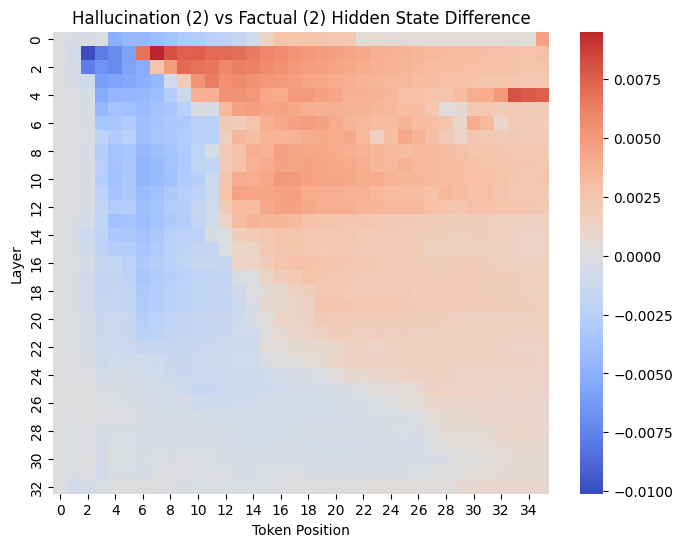

Standard deviation: 0.0024332343600690365


In [173]:
hidd_diff = (
    (hidden_scores["hallucination1"] + hidden_scores["hallucination2"]) / 2
    - (hidden_scores["factual"] + hidden_scores["factual2"]) / 2
)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(hidd_diff[0, :, :].detach().cpu().numpy(), ax=ax, cmap="coolwarm", center=0)
ax.set_title(f"Hallucination (2) vs Factual (2) Hidden State Difference")
ax.set_ylabel("Layer")
ax.set_xlabel("Token Position")
plt.show()

score_diffs["hallucination_vs_factual"] = hidd_diff.clone()

print("Standard deviation:", hidd_diff.std().item())

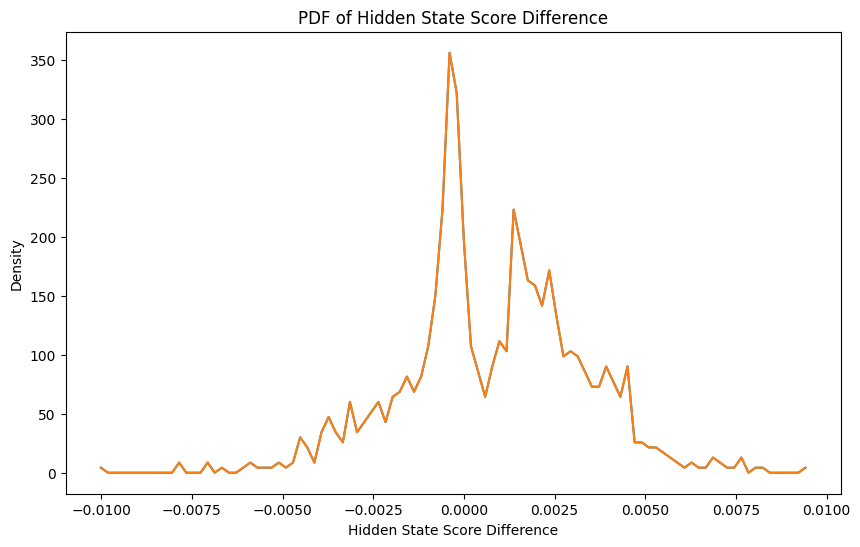

In [181]:
plt.figure(figsize=(10, 6))
bin_centers, hist = get_pdf(score_diffs["hallucination_vs_factual"], num_bins=100)
plt.plot(bin_centers.detach().cpu().numpy(), hist.detach().cpu().numpy())
plt.title("PDF of Hidden State Score Difference")
plt.xlabel("Hidden State Score Difference")
plt.ylabel("Density")
plt.show()

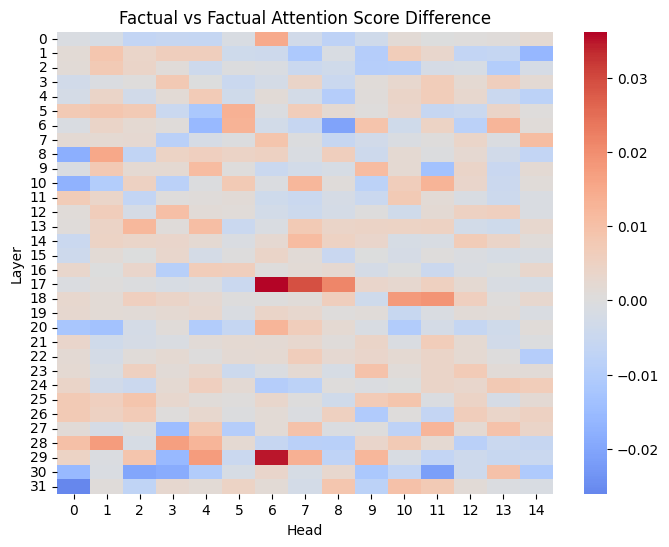

Standard Deviation: 0.012070919387042522


In [191]:
att_diff = (
    attention_scores["factual"] 
    - attention_scores["factual2"] 
)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(att_diff[0, :, :].mean(dim=-1).detach().cpu().numpy(), ax=ax, cmap="coolwarm", center=0)
ax.set_title(f"Factual vs Factual Attention Score Difference")
ax.set_ylabel("Layer")
ax.set_xlabel("Head")
plt.show()

print("Standard Deviation:", att_diff.std().item())

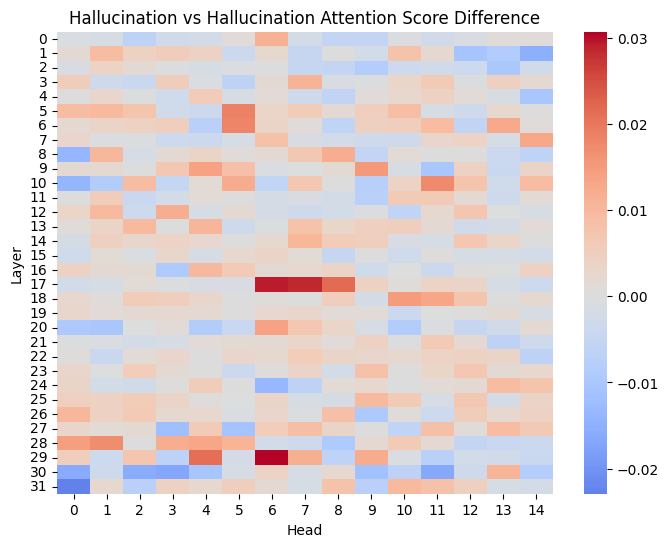

Standard Deviation: 0.011102067306637764


In [190]:
att_diff = (
    attention_scores["hallucination1"] 
    - attention_scores["hallucination2"] 
)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(att_diff[0, :, :].mean(dim=-1).detach().cpu().numpy(), ax=ax, cmap="coolwarm", center=0)
ax.set_title(f"Hallucination vs Hallucination Attention Score Difference")
ax.set_ylabel("Layer")
ax.set_xlabel("Head")
plt.show()

print("Standard Deviation:", att_diff.std().item())

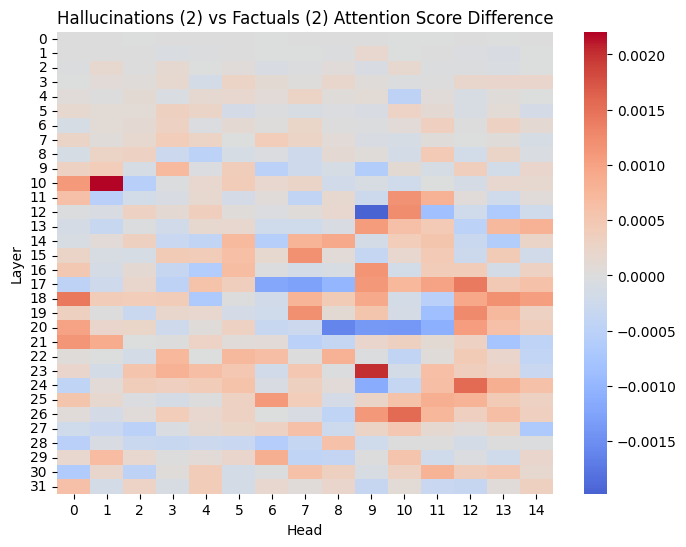

Standard Deviation: 0.0014323815703392029


In [189]:
att_diff = (
    (attention_scores["hallucination1"] + attention_scores["hallucination2"]) / 2
    - (attention_scores["factual"] + attention_scores["factual2"]) / 2
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(att_diff[0, :, :].mean(dim=-1).detach().cpu().numpy(), ax=ax, cmap="coolwarm", center=0)
ax.set_title(f"Hallucinations (2) vs Factuals (2) Attention Score Difference")
ax.set_ylabel("Layer")
ax.set_xlabel("Head")
plt.show()

print("Standard Deviation:", att_diff.std().item())

### Score distribution similarity analysis

Global hidden-state distribution comparison:
wasserstein: 0.010830419771498697
energy: 0.005278367920451522
ks_pvalue: 0.9999999999999901
mwu_pvalue: 0.9632207774664664
mmd2: -0.0003800392150878906


/var/home/joaofonseca/miniconda3/envs/llm/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


,layer,wasserstein,energy,ks_p,mwu_p,mmd2
0,0,0.013844,0.027733,1.0,0.914796,-0.025708
1,1,0.019786,0.033155,1.0,0.905866,-0.024816
2,2,0.020551,0.033790,1.0,0.923735,-0.024892
3,3,0.017109,0.030831,1.0,0.941643,-0.025095
4,4,0.023547,0.036169,1.0,0.968557,-0.025855
...,...,...,...,...,...,...
61,61,0.002129,0.010876,1.0,0.932685,-0.026420
62,62,0.002612,0.012045,1.0,0.888045,-0.026383
63,63,0.002801,0.012475,1.0,0.923735,-0.026452
64,64,0.001438,0.008939,1.0,0.977538,-0.026353


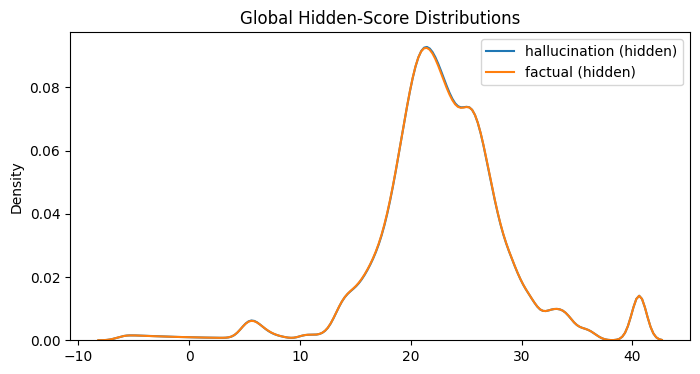

/var/home/joaofonseca/miniconda3/envs/llm/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


,layer,head,wasserstein,energy,ks_p,mwu_p,mmd2
0,0,0,0.001560,0.009309,1.0,0.995506,-0.024616
1,0,1,0.001736,0.009820,1.0,0.995506,-0.024642
2,0,2,0.011690,0.025484,1.0,0.986518,-0.024188
3,0,3,0.010739,0.024425,1.0,0.986518,-0.024180
4,0,4,0.008729,0.022022,1.0,0.986518,-0.024321
5,0,5,0.008659,0.021933,1.0,0.986518,-0.024313
6,0,6,0.089023,0.070326,1.0,0.986518,-0.024120
7,0,7,0.087214,0.069608,1.0,0.986518,-0.024034
8,0,8,0.108133,0.092285,1.0,0.977532,-0.024564
9,0,9,0.107004,0.091719,1.0,0.977532,-0.024649


Fraction of (layer,head) pairs with KS p>0.05: 1.000


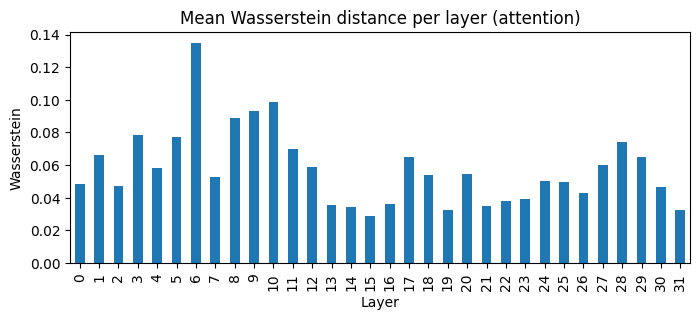

Done — global + per-layer/head distribution comparisons computed.


In [135]:
# Distribution similarity analysis between hallucination vs factual responses
# Computes: Wasserstein, Energy distance, KS-test p-value, Mann-Whitney U p-value, and RBF-MMD^2.
# Produces global comparisons (all scores) and per-layer / per-head summaries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance, ks_2samp, energy_distance, mannwhitneyu

# RBF MMD (unbiased) implementation
def rbf_kernel(x, y, gamma):
    x = x.reshape(-1, 1) if x.ndim == 1 else x
    y = y.reshape(-1, 1) if y.ndim == 1 else y
    xx = np.sum((x[:, None, :] - x[None, :, :])**2, axis=-1)
    yy = np.sum((y[:, None, :] - y[None, :, :])**2, axis=-1)
    xy = np.sum((x[:, None, :] - y[None, :, :])**2, axis=-1)
    kxx = np.exp(-gamma * xx)
    kyy = np.exp(-gamma * yy)
    kxy = np.exp(-gamma * xy)
    return kxx, kyy, kxy

def mmd2_rbf(x, y, gamma=None):
    x = np.asarray(x).reshape(-1, 1) if np.asarray(x).ndim == 1 else np.asarray(x)
    y = np.asarray(y).reshape(-1, 1) if np.asarray(y).ndim == 1 else np.asarray(y)
    if gamma is None:
        # median heuristic on pairwise distances of combined data
        z = np.vstack([x.reshape(-1, x.shape[-1]), y.reshape(-1, y.shape[-1])]) if x.ndim > 1 else np.concatenate([x.ravel(), y.ravel()])[:, None]
        dists = np.sqrt(np.sum((z[:, None, :] - z[None, :, :])**2, axis=-1)).ravel()
        med = np.median(dists[dists > 0]) if np.any(dists > 0) else 1.0
        gamma = 1.0 / (2 * (med**2))
    kxx, kyy, kxy = rbf_kernel(x, y, gamma)
    nx = x.shape[0]
    ny = y.shape[0]
    # unbiased estimator (diagonals removed)
    sum_kxx = (np.sum(kxx) - np.sum(np.diag(kxx))) / (nx * (nx - 1)) if nx > 1 else 0.0
    sum_kyy = (np.sum(kyy) - np.sum(np.diag(kyy))) / (ny * (ny - 1)) if ny > 1 else 0.0
    sum_kxy = np.sum(kxy) / (nx * ny)
    return sum_kxx + sum_kyy - 2 * sum_kxy

# Helper to gather keys for hallucination/factual groups (flexible)
def find_keys(dct, prefix):
    return [k for k in dct.keys() if prefix in k]

# Require `hidden_scores` and `attention_scores` to exist (computed earlier in notebook)
if not ('hidden_scores' in globals() and 'attention_scores' in globals()):
    raise RuntimeError('Expected `hidden_scores` and `attention_scores` dicts from earlier cells.')

# Choose keys present in notebook (fallbacks)
hall_keys = [k for k in hidden_scores.keys() if 'halluc' in k.lower()] or ['hallucination1', 'hallucination2']
fact_keys = [k for k in hidden_scores.keys() if 'fact' in k.lower()] or ['factual', 'factual2']

# --- Hidden states: global and per-layer comparisons ---
def gather_hidden_group(keys):
    arrays = []
    for k in keys:
        t = hidden_scores.get(k)
        if t is None:
            continue
        a = t.detach().cpu().numpy().squeeze()  # (num_layers, seq_len) or similar
        arrays.append(a)
    if not arrays:
        return None
    return np.concatenate([arr.reshape(-1, arr.shape[-1]) if arr.ndim==3 else arr for arr in arrays], axis=0) if any(arr.ndim==3 for arr in arrays) else np.concatenate(arrays, axis=0)

H_hall = gather_hidden_group(hall_keys)
H_fact = gather_hidden_group(fact_keys)
if H_hall is None or H_fact is None:
    raise RuntimeError('Could not locate hidden_scores entries for hallucination/factual keys: %s %s' % (hall_keys, fact_keys))
# If arrays are 2D (num_layers, seq_len) we can aggregate per-layer easily
if H_hall.ndim == 1:
    H_hall = H_hall[None, :]
if H_fact.ndim == 1:
    H_fact = H_fact[None, :]
# If shapes differ in rows (due to concatenation across runs), we will treat rows as independent examples
# Global flattened distributions (all layers x tokens)
A = H_hall.reshape(-1)
B = H_fact.reshape(-1)

global_metrics = dict()
global_metrics['wasserstein'] = wasserstein_distance(A, B)
global_metrics['energy'] = energy_distance(A, B)
ks_stat, ks_p = ks_2samp(A, B)
global_metrics['ks_pvalue'] = ks_p
mwu_stat, mwu_p = mannwhitneyu(A, B, alternative='two-sided')
global_metrics['mwu_pvalue'] = mwu_p
global_metrics['mmd2'] = mmd2_rbf(A, B)

print('Global hidden-state distribution comparison:')
for k, v in global_metrics.items():
    print(f'{k}: {v}')

# Per-layer summary (treat rows as layers when shape matches)
n_layers = min(H_hall.shape[0], H_fact.shape[0])
rows = []
for layer in range(n_layers):
    x = H_hall[layer].ravel()
    y = H_fact[layer].ravel()
    ws = wasserstein_distance(x, y)
    ed = energy_distance(x, y)
    ks_s, ks_p = ks_2samp(x, y)
    mwu_s, mwu_p = mannwhitneyu(x, y, alternative='two-sided')
    mmd2 = mmd2_rbf(x, y)
    rows.append({'layer': layer, 'wasserstein': ws, 'energy': ed, 'ks_p': ks_p, 'mwu_p': mwu_p, 'mmd2': mmd2})
df_layers = pd.DataFrame(rows)
display(df_layers)

# Plot global PDFs / KDEs
plt.figure(figsize=(8, 4))
sns.kdeplot(A, label='hallucination (hidden)', bw_adjust=0.5)
sns.kdeplot(B, label='factual (hidden)', bw_adjust=0.5)
plt.legend()
plt.title('Global Hidden-Score Distributions')
plt.show()

# --- Attention scores: per (layer, head) comparisons ---
# attention_scores entries are expected shape: (batch, num_layers, num_heads, seq_len) or (num_layers, num_heads, seq_len)
def gather_attention_group(keys):
    arrays = []
    for k in keys:
        t = attention_scores.get(k)
        if t is None:
            continue
        a = t.detach().cpu().numpy().squeeze()  # ensure numpy
        # normalize dims to (num_layers, num_heads, seq_len)
        if a.ndim == 4:
            # (batch, num_layers, num_heads, seq_len) -> move batch into runs dimension
            a = a.transpose(1,2,0,3)  # (num_layers, num_heads, batch, seq_len)
        if a.ndim == 3:
            arrays.append(a)
    if not arrays:
        return None
    # stack along runs axis: (runs, num_layers, num_heads, seq_len)
    stacked = np.stack(arrays, axis=0)
    runs, L, H, S = stacked.shape
    # reshape to (num_layers, runs*num_heads, seq_len) so we can pool heads from different runs
    return stacked.transpose(1,2,0,3).reshape(L, H * runs, S)

A_att = gather_attention_group(hall_keys)
B_att = gather_attention_group(fact_keys)
if A_att is None or B_att is None:
    print('Warning: could not gather attention groups for keys', hall_keys, fact_keys)
else:
    rows = []
    L = min(A_att.shape[0], B_att.shape[0])
    for layer in range(L):
        Hn = min(A_att.shape[1], B_att.shape[1])
        for head in range(Hn):
            x = A_att[layer, head].ravel()
            y = B_att[layer, head].ravel()
            ws = wasserstein_distance(x, y)
            ed = energy_distance(x, y)
            ks_s, ks_p = ks_2samp(x, y)
            mwu_s, mwu_p = mannwhitneyu(x, y, alternative='two-sided')
            mmd2 = mmd2_rbf(x, y)
            rows.append({'layer': layer, 'head': head, 'wasserstein': ws, 'energy': ed, 'ks_p': ks_p, 'mwu_p': mwu_p, 'mmd2': mmd2})
    df_att = pd.DataFrame(rows)
    display(df_att.head(40))
    # summarize: fraction of (layer,head) pairs where KS-test fails to reject (p>0.05)
    frac_similar = (df_att['ks_p'] > 0.05).mean()
    print(f'Fraction of (layer,head) pairs with KS p>0.05: {frac_similar:.3f}')

    # Visualize Wasserstein per-layer (mean over heads)
    gp = df_att.groupby('layer')['wasserstein'].mean()
    plt.figure(figsize=(8,3))
    gp.plot(kind='bar')
    plt.title('Mean Wasserstein distance per layer (attention)')
    plt.xlabel('Layer')
    plt.ylabel('Wasserstein')
    plt.show()

print('Done — global + per-layer/head distribution comparisons computed.')

In [139]:
df_att["mwu_p"].min()

np.float64(0.959569878968065)

In [143]:
# Compute Cohen's d, bootstrap CIs, permutation p-values for Wasserstein, and BH correction
import numpy as np
from scipy.stats import wasserstein_distance

def cohens_d(x, y):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    mx, my = x.mean(), y.mean()
    sx = x.var(ddof=1)
    sy = y.var(ddof=1)
    pooled = np.sqrt(((nx - 1) * sx + (ny - 1) * sy) / (nx + ny - 2))
    return (mx - my) / pooled if pooled > 0 else np.nan

def bootstrap_ci_diff(func, x, y, n_boot=1000, alpha=0.05, rng=None):
    rng = np.random.default_rng(rng)
    stats = []
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    nx, ny = len(x), len(y)
    for _ in range(n_boot):
        sx = rng.choice(x, size=nx, replace=True)
        sy = rng.choice(y, size=ny, replace=True)
        stats.append(func(sx, sy))
    lo = np.percentile(stats, 100 * (alpha / 2))
    hi = np.percentile(stats, 100 * (1 - alpha / 2))
    return lo, hi

def perm_wasserstein_p(x, y, n_perms=1000, rng=None):
    rng = np.random.default_rng(rng)
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    obs = wasserstein_distance(x, y)
    comb = np.concatenate([x, y])
    n = len(x)
    count = 0
    for _ in range(n_perms):
        rng.shuffle(comb)
        px = comb[:n].copy()
        py = comb[n:].copy()
        if wasserstein_distance(px, py) >= obs:
            count += 1
    return (count + 1) / (n_perms + 1), obs

def bh_adjust(pvals):
    p = np.asarray(pvals).astype(float)
    n = len(p)
    order = np.argsort(p)
    sorted_p = p[order]
    adjusted = np.empty(n, dtype=float)
    # Benjamini-Hochberg adjustment
    for i, pv in enumerate(sorted_p, start=1):
        adjusted[i-1] = pv * n / i
    # enforce monotonicity from largest to smallest
    for i in range(n-2, -1, -1):
        adjusted[i] = min(adjusted[i], adjusted[i+1])
    # map back to original order and cap at 1
    adj = np.empty(n, dtype=float)
    adj[order] = np.minimum(adjusted, 1.0)
    return adj

# Ensure df_layers and df_att exist
if 'df_layers' not in globals():
    print('df_layers not found; run the distribution cell first')
else:
    # Per-layer: compute Cohen's d, bootstrap CI, permutation p for Wasserstein
    layer_stats = []
    for layer in range(df_layers.shape[0]):
        # retrieve original arrays if available from H_hall/H_fact; otherwise reconstruct from H_hall/H_fact in globals
        try:
            x = H_hall[layer].ravel()
            y = H_fact[layer].ravel()
        except Exception:
            # fallback: use df_layers aggregated values (only metrics present)
            layer_stats.append({'layer': layer, 'cohens_d': np.nan, 'd_ci': (np.nan, np.nan), 'perm_w_p': np.nan, 'wass': df_layers.loc[layer, 'wasserstein']})
            continue
        d = cohens_d(x, y)
        lo, hi = bootstrap_ci_diff(cohens_d, x, y, n_boot=500)
        p_perm, obs_w = perm_wasserstein_p(x, y, n_perms=500)
        layer_stats.append({'layer': layer, 'cohens_d': d, 'd_ci': (lo, hi), 'perm_w_p': p_perm, 'wass': obs_w})
    df_layer_stats = pd.DataFrame(layer_stats)
    display(df_layer_stats)

if 'df_att' not in globals():
    print('df_att not found; run the distribution cell first')
else:
    # Per-(layer,head): compute Cohen's d and collect p-values for BH correction
    att_stats = []
    pvals = []
    for idx, row in df_att.iterrows():
        layer = int(row['layer'])
        head = int(row['head'])
        try:
            x = A_att[layer, head].ravel()
            y = B_att[layer, head].ravel()
        except Exception:
            att_stats.append({'layer': layer, 'head': head, 'cohens_d': np.nan, 'perm_w_p': np.nan})
            pvals.append(np.nan)
            continue
        d = cohens_d(x, y)
        p_perm, _ = perm_wasserstein_p(x, y, n_perms=300)
        att_stats.append({'layer': layer, 'head': head, 'cohens_d': d, 'perm_w_p': p_perm})
        pvals.append(p_perm)
    df_att_stats = pd.DataFrame(att_stats)
    # BH adjust permutation p-values (ignore NaNs)
    valid = ~np.isnan(pvals)
    adj = np.full(len(pvals), np.nan)
    if valid.sum() > 0:
        adj_vals = bh_adjust(np.array(pvals)[valid])
        adj[valid] = adj_vals
    df_att_stats['perm_w_p_bh'] = adj
    display(df_att_stats.head(40))
    # show top divergent heads by Cohen's d (abs)
    top_heads = df_att_stats.reindex(df_att_stats['cohens_d'].abs().sort_values(ascending=False).index).head(10)
    print('Top divergent heads by |Cohens d|:')
    display(top_heads)

print('Computed Cohens d, bootstrap CIs, permutation p-values, and applied BH adjustment for attention tests.')

,layer,cohens_d,d_ci,perm_w_p,wass
0,0,-0.002054,"(-0.57454765, 0.41566855)",1.0,0.013844
1,1,-0.002381,"(-0.5171981, 0.42058426)",1.0,0.019786
2,2,-0.002060,"(-0.47286332, 0.48048788)",1.0,0.020551
3,3,-0.003902,"(-0.4971745, 0.50866795)",1.0,0.017109
4,4,-0.000351,"(-0.51967263, 0.42502448)",1.0,0.023547
...,...,...,...,...,...
61,61,0.000471,"(-0.45682004, 0.4582839)",1.0,0.002129
62,62,0.000743,"(-0.4631951, 0.44653347)",1.0,0.002612
63,63,0.000762,"(-0.49886394, 0.4730278)",1.0,0.002801
64,64,0.000168,"(-0.5016728, 0.44434386)",1.0,0.001438


,layer,head,cohens_d,perm_w_p,perm_w_p_bh
0,0,0,-0.000028,1.0,1.0
1,0,1,0.000047,1.0,1.0
2,0,2,0.000426,1.0,1.0
3,0,3,-0.000393,1.0,1.0
4,0,4,0.000300,1.0,1.0
5,0,5,-0.000301,1.0,1.0
6,0,6,0.002427,1.0,1.0
7,0,7,-0.002394,1.0,1.0
8,0,8,0.005567,1.0,1.0
9,0,9,-0.005582,1.0,1.0


Top divergent heads by |Cohens d|:


,layer,head,cohens_d,perm_w_p,perm_w_p_bh
43,1,13,-0.008690,1.0,1.0
42,1,12,0.008616,1.0,1.0
197,6,17,-0.008202,1.0,1.0
196,6,16,0.008083,1.0,1.0
897,29,27,-0.007409,1.0,1.0
307,10,7,-0.006781,1.0,1.0
306,10,6,0.006402,1.0,1.0
328,10,28,0.006328,1.0,1.0
91,3,1,-0.006141,1.0,1.0
90,3,0,0.006110,1.0,1.0


Computed Cohens d, bootstrap CIs, permutation p-values, and applied BH adjustment for attention tests.


In [141]:
df_layers.min()

layer          0.000000
wasserstein    0.001438
energy         0.008939
ks_p           1.000000
mwu_p          0.843757
mmd2          -0.026553
dtype: float64


mwu_p is generally high -> cannot reject null hypothesis that distributions are the same

wasserstein and energy distances are low -> distributions are similar

MMD^2 is also low, indicating similarity between distributions

Overall, this suggests that the hidden state and attention score distributions 
for hallucination and factual responses are quite similar in this analysis.

# Tests

In [115]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2", attn_implementation="eager")

inputs = tokenizer("Your input text here", return_tensors="pt")
outputs = model(**inputs, output_attentions=True)

# outputs.attentions is a tuple with one entry per layer:
# each entry shape: (batch_size, num_heads, seq_len, seq_len)
layer_idx = 0  # choose your layer
head_idx = 0   # choose your head

attention_matrix = outputs.attentions[layer_idx][0, head_idx].detach().cpu().numpy()


In [116]:
attention_matrix

array([[1.        , 0.        , 0.        , 0.        ],
       [0.79148906, 0.20851088, 0.        , 0.        ],
       [0.64886886, 0.28307122, 0.06805992, 0.        ],
       [0.6027606 , 0.21170728, 0.1395562 , 0.04597589]], dtype=float32)